<a href="https://colab.research.google.com/github/cellrishi-code/Unsupervised-learning/blob/main/ica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Independent Component Analysis (ICA)

## 1. Brief Overview

ICA is an **unsupervised learning algorithm** used for **blind source separation** and **feature extraction**. There are no labels — ICA is given only a bunch of *mixed* signals and has to figure out, on its own, what the original *unmixed* signals probably were.

The classic motivating example is the **cocktail party problem**: several people talk at once in a room, and several microphones each pick up a different blend of every voice. Given only the microphone recordings, can you recover each person's voice individually?

> Given several mixtures of unknown signals, recover the original signals -- without knowing how they were mixed.

ICA's answer: yes, **if** the original signals were **statistically independent** and **not Gaussian**. It finds a linear transformation of the observed mixtures that makes the recovered components as statistically independent as possible.


## 2. The Mathematics

**The model.** There are $n$ unknown, mutually independent sources $\mathbf{s}$ that we never see. We only observe linear mixtures $\mathbf{x} = A\mathbf{s}$, where $A$ (the mixing matrix) is also unknown. The goal is an **unmixing matrix** $W$ such that $\hat{\mathbf{s}} = W\mathbf{x} \approx \mathbf{s}$.

> **A concrete example, in numbers.** Say Alice and Bob speak at once, picked up by 2 microphones. At one instant, Alice's voice amplitude is $s_1=1$ and Bob's is $s_2=2$. Mic 1 sits closer to Alice, Mic 2 closer to Bob, so each mic records a *weighted sum* of both voices:
> $$x_1 = 0.8\,s_1 + 0.2\,s_2 = 0.8(1) + 0.2(2) = 1.2 \qquad x_2 = 0.3\,s_1 + 0.7\,s_2 = 0.3(1) + 0.7(2) = 1.7$$
> That's the linear transformation $\mathbf{x}=A\mathbf{s}$ in action, with $A=\begin{bmatrix}0.8&0.2\\0.3&0.7\end{bmatrix}$: each mic's reading is just a fixed weighted blend of the two voices, repeated at every instant in time. ICA watches many such $(x_1,x_2)$ pairs over time and works backward to a $W$ that undoes the blend -- recovering something close to $(s_1,s_2)$ again, without ever being told $A$.

> **Where $W$ comes in.** If we happened to know $A$, we could just invert it: $W=A^{-1}=\begin{bmatrix}1.4&-0.4\\-0.6&1.6\end{bmatrix}$. Applying it to the observed mixture $\mathbf{x}=(1.2,1.7)$ gives $\hat s_1 = 1.4(1.2)-0.4(1.7)=1.0$ and $\hat s_2=-0.6(1.2)+1.6(1.7)=2.0$ -- exactly $(s_1,s_2)$ again, $W$ undid $A$'s mixing perfectly. The catch: in real problems $A$ is unknown, so we can't just invert it. Instead, ICA estimates $W$ **directly from the observed data**, by searching for the rows of $W$ that make $W\mathbf{x}$ as independent (equivalently, as non-Gaussian -- see "the key trick" below) as possible -- without ever seeing $A$ or $\mathbf{s}$.

**Why not just PCA?** PCA only forces components to be *uncorrelated* (a 2nd-order-statistics condition). *Independence* is a much stronger condition — it constrains the whole joint distribution, not just covariance.

> **The formulas, side by side.**
>
> **Correlation** (Pearson's $\rho$) measures *linear* association on a $-1$ to $1$ scale:
> $$\rho_{X,Y} = \frac{\mathrm{Cov}(X,Y)}{\sigma_X\,\sigma_Y} = \frac{\mathbb{E}[XY]-\mathbb{E}[X]\,\mathbb{E}[Y]}{\sigma_X\sigma_Y}$$
> **Uncorrelated** is just the special case $\rho_{X,Y}=0$, i.e. $\mathrm{Cov}(X,Y)=\mathbb{E}[XY]-\mathbb{E}[X]\mathbb{E}[Y]=0$.
>
> **Independent** is a stronger, different kind of statement — not a single number, but a condition on the *entire joint distribution*:
> $$p(x,y) = p(x)\,p(y) \;\; \text{for every } x,y \quad\Longleftrightarrow\quad \mathbb{E}[g(X)h(Y)] = \mathbb{E}[g(X)]\,\mathbb{E}[h(Y)] \;\text{ for ANY functions } g,h$$
>



## 3. Where ICA is used, theoretically

ICA applies whenever data is plausibly a **linear mixture of independent, non-Gaussian underlying causes**, and you want to recover those causes rather than just compress variance (which is what PCA is for). Typical domains:

- **Audio / speech separation** — the cocktail-party problem itself: separating overlapping speakers from multi-microphone recordings, or demixing vocals/instruments in a music track ("unmixing" stems).
- **Biomedical signal processing** — removing eye-blink and muscle-movement artifacts from EEG/MEG recordings (the artifact is statistically independent of the brain signal of interest); identifying independent functional brain networks in fMRI data.
- **Telecommunications** — separating co-channel signals in wireless/MIMO systems, where multiple independent transmitters' signals arrive superimposed at an antenna array.
- **Image processing / computational neuroscience** — running ICA on patches of natural images recovers edge-detector-like filters strikingly similar to the receptive fields of simple cells in the mammalian visual cortex (Bell & Sejnowski, Olshausen & Field) — a well-known theoretical link between "maximize statistical independence" and how early biological vision appears to encode images. The same idea is used practically for texture/feature extraction (e.g. the "ICA-faces" bonus below).
- **Finance / econometrics** — extracting a small number of latent, independent risk factors or economic drivers from a large panel of correlated asset returns.
- **General feature learning / dimensionality reduction** — as an alternative to PCA whenever the *downstream* task benefits from independent, sparse, part-like features rather than merely uncorrelated, variance-ranked ones (e.g. as a preprocessing step before a classifier).

The common thread: ICA is the right tool whenever "uncorrelated" (PCA's answer) isn't good enough and you specifically believe the true generating factors are **independent** — not just orthogonal.


## 4. Demo using scikit-learn

We'll reproduce the classic **cocktail party problem**: 3 synthetic "voices" (a sine, a square, and a sawtooth wave -- all non-Gaussian) are linearly mixed into 3 synthetic "microphone" signals, and `FastICA` is used to recover the originals from the mixtures alone.

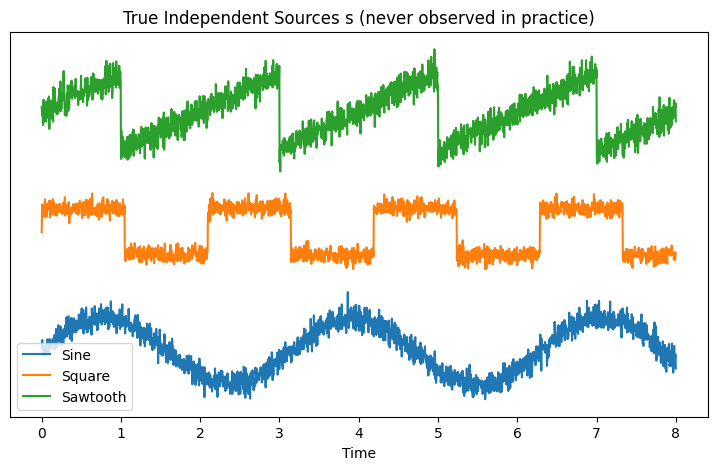

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 3 independent, non-Gaussian source signals -- ICA needs non-Gaussian sources (section 2).
rng = np.random.RandomState(42)
n_samples = 2000
time = np.linspace(0, 8, n_samples)

s1 = np.sin(2 * time)                                    # sine wave
s2 = np.sign(np.sin(3 * time))                            # square wave
s3 = 2 * (time * 0.5 - np.floor(time * 0.5 + 0.5))        # sawtooth wave

S = np.c_[s1, s2, s3]
S += 0.2 * rng.normal(size=S.shape)
S /= S.std(axis=0)                    # standardize

plt.figure(figsize=(9, 5))
for i, label in enumerate(["Sine", "Square", "Sawtooth"]):
    plt.plot(time, S[:, i] + i * 5, label=label)
plt.title("True Independent Sources s (never observed in practice)")
plt.xlabel("Time")
plt.yticks([])
plt.legend()
plt.show()

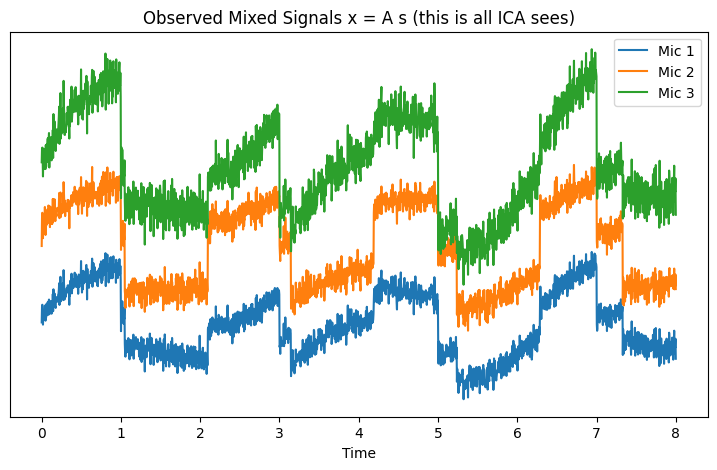

In [ ]:
# Mix the sources into observed signals: x = A s
A_true = np.array([[1.0, 1.0, 1.0],
                    [0.5, 2.0, 1.0],
                    [1.5, 1.0, 2.0]])   # unknown-in-practice mixing matrix

X = S.dot(A_true.T)   # X is the ONLY thing ICA gets to see

plt.figure(figsize=(9, 5))
for i, label in enumerate(["Mic 1", "Mic 2", "Mic 3"]):
    plt.plot(time, X[:, i] + i * 5, label=label)
plt.title("Observed Mixed Signals x = A s (this is all ICA sees)")
plt.xlabel("Time")
plt.yticks([])
plt.legend()
plt.show()

In [ ]:
from sklearn.decomposition import FastICA

# whiten="unit-variance" performs the centering + whitening internally before the
ica = FastICA(n_components=3, whiten="unit-variance", random_state=42)
S_recovered = ica.fit_transform(X)   # estimated sources s_hat = W x
A_recovered = ica.mixing_            # estimated mixing matrix

print("Estimated mixing matrix A_hat:\n", A_recovered)
print("\nTrue mixing matrix A (for comparison -- ICA never sees this):\n", A_true)


Estimated mixing matrix A_hat:
 [[ 0.99103927  1.72873363 -0.53437093]
 [ 0.5177987   2.67405741 -0.29906139]
 [ 1.45768052  2.45192126 -1.27102807]]

True mixing matrix A (for comparison -- ICA never sees this):
 [[1.  1.  1. ]
 [0.5 2.  1. ]
 [1.5 1.  2. ]]


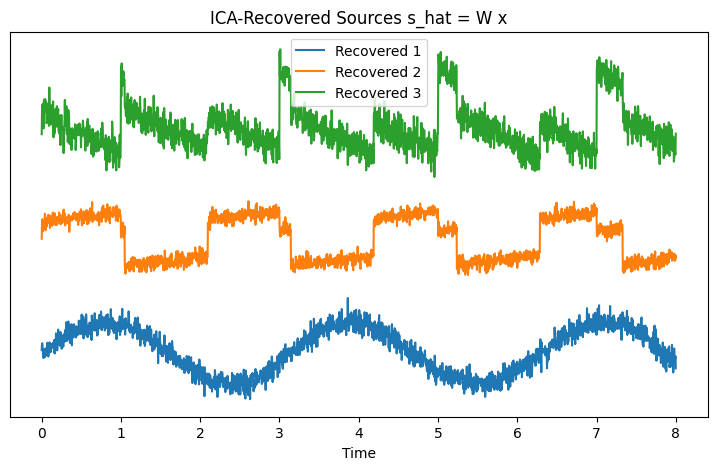

In [ ]:
plt.figure(figsize=(9, 5))
for i, label in enumerate(["Recovered 1", "Recovered 2", "Recovered 3"]):
    plt.plot(time, S_recovered[:, i] + i * 5, label=label)
plt.title("ICA-Recovered Sources s_hat = W x")
plt.xlabel("Time")
plt.yticks([])
plt.legend()
plt.show()

## 5. Limitations and Drawbacks

ICA is powerful but not a free lunch — several of its own assumptions can break in practice:

- **At most one Gaussian source.** If two or more true sources are Gaussian, their mixture is statistically indistinguishable from any rotation of them, so ICA provably cannot separate them.
- **Needs at least as many sensors as sources.** With $m$ mixtures and $n>m$ true sources, $A$ isn't invertible and standard ICA can't fully recover every source.
- **No natural ranking of components.** Unlike PCA (ranked by variance explained), ICA gives back components in arbitrary order with no built-in notion of "importance" — you must inspect or match them manually to know which one matters.
- **Permutation, sign & scale ambiguity.** As noted in section 2, recovered components can come back reordered, flipped in sign, and rescaled — fine for separation demos, but inconvenient whenever a fixed, consistent output ordering is required.
- **Sensitive to sensor noise.** The classic derivation assumes noise-free mixtures; real additive noise degrades separation quality (noisy-ICA variants exist but are more complex to fit).
- **Non-convex optimization.** The fixed-point search can converge to different — sometimes poor — solutions depending on initialization, so results can change with the `random_state` and aren't guaranteed to be globally optimal.
- **More data-hungry than PCA.** Because it relies on higher-order statistics (kurtosis/negentropy) rather than just covariance, ICA typically needs more samples to get statistically reliable estimates.


## 6. Online Resources

- [scikit-learn: Independent Component Analysis (ICA) user guide](https://scikit-learn.org/stable/modules/decomposition.html#ica)
- [scikit-learn: `FastICA` API reference](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FastICA.html)
- [scikit-learn example: Blind source separation using FastICA](https://scikit-learn.org/stable/auto_examples/decomposition/plot_ica_blind_source_separation.html)
- [scikit-learn example: FastICA vs PCA on faces](https://scikit-learn.org/stable/auto_examples/decomposition/plot_faces_decomposition.html)
- Hyvärinen, A. & Oja, E. (2000). ["Independent Component Analysis: Algorithms and Applications"](https://www.cs.helsinki.fi/u/ahyvarin/papers/NN00new.pdf), *Neural Networks*, 13(4-5), 411-430 -- the original FastICA paper.
